# **Project 2: Implementing Simple Linear Regression with Ordinary Least Squares (OLS) and Sum of Squared Errors (SSE) equations**

### **Names:** David Kim (rcy3cs), Chloe Wang (qtr7bs), Isra Abudiab (mjv3cp)

## **Objective**
In this assignment, you will implement simple linear regression from scratch using only NumPy and base Python. You will:

- Express linear regression in **matrix notation**.
- Compute the **line of best fit** using **OLS**.
- Calculate the **sum of squared errors (SSE)** to evaluate the model.

By the end of this assignment, you will understand how to derive and implement **linear regression** in its fundamental mathematical form.

---

## **Background**

### **Linear Regression Equation**
Simple linear regression is expressed as:


\begin{equation}
y = mx + b
\end{equation}


where:
- \( y \) is the **dependent variable** (target),
- \( x \) is the **independent variable** (feature),
- \( m \) is the **slope** (coefficient),
- \( b \) is the **y-intercept**.

---

### **Matrix Form**
We can express the equation in **matrix notation**:

\begin{equation}
Y = X \beta
\end{equation}

where:
- \$ Y \$ is an \$ n \times 1 \$ vector of observed values:

  \begin{aligned}
  Y =
  \begin{bmatrix}
  y_1 \\
  y_2 \\
  \vdots \\
  y_n
  \end{bmatrix}
  \end{aligned}

- \$ X \$ is an \$ n \times 2 \$ **design matrix**, where the first column consists of ones (for the intercept) and the second column contains the \$ x \$ values:

  \begin{aligned}
  X =
  \begin{bmatrix}
  1 & x_1 \\
  1 & x_2 \\
  \vdots & \vdots \\
  1 & x_n
  \end{bmatrix}
  \end{aligned}

- \$ \beta \$ is a \$ 2 \times 1 \$ vector containing the intercept \$( b \$) and slope \$( m \$):

  \begin{aligned}
  \beta =
  \begin{bmatrix}
  b \\
  m
  \end{bmatrix}
  \end{aligned}

Thus, our model can be rewritten as:

\begin{aligned}
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
&=
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
\begin{bmatrix}
b \\
m
\end{bmatrix}
\end{aligned}

---

### **Computing the Best Fit Line Using the ordinary least squares (OLS)**
The **best fit line** is obtained using the **ordinary least squares (OLS)**:

\begin{equation}
\beta = (X^T X)^{-1} X^T Y
\end{equation}

where:
- \$ X^T \$ is the transpose of \$ X \$,
- \$ (X^T X)^{-1} \$ is the **inverse** of \$ X^T X \$,
- \$ X^T Y \$ is the product of the transposed \$ X \$ and \$ Y \$.
---

### **Sum of Squared Errors (SSE)**
The **sum of squared errors (SSE)** is used to measure how well the regression line fits the data:


\begin{equation}
SSE = \frac{1}{n}\sum_{i=1}^{n} \|y_i - \hat{y}_i\|^2
\end{equation}

where:
- \$ y_i \$ represents the actual observed values,
- \$ \hat{y}_i \$ are the predicted values from the model.

Alternatively, using matrix notation:

\begin{equation}
SSE = (Y - X \beta)^T (Y - X \beta)
\end{equation}

where \$ Y - X\beta \$ represents the **residuals** (differences between actual and predicted values).

---

### **Coding**


###1. Import Required Libraries
For this lab only use NumPy, Pandas, Matplotlib, and base Python.

In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

###2. Data

* We have a data set that describes 506 suburbs in Boston. Find the documentation for the variables [here](https://islp.readthedocs.io/en/latest/datasets/Boston.html).
* *Goal*: Predict the median value (in $1000s) of houses owned in that suburb.
* *Task*: Use the covariates / indepednent variables from the data set to create 3 different types of predictive models: single variable, multivariable, and polynomial regression.

**First step: import the data, split into x and y, and turn them into numpy arrays.**

In [254]:
#https://islp.readthedocs.io/en/latest/datasets/Boston.html
df = pd.read_csv('https://raw.githubusercontent.com/intro-stat-learning/ISLP/refs/heads/main/ISLP/data/Boston.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [255]:
# remove the last column because we cannot use the dependent variable in the model
x = df.iloc[:, :-1]
x.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33


**Begin with a single variable model, selecting the 6th column: 'rm' (average number of rooms per dwelling)**

In [256]:
# Starting with single linear regression
x = df.iloc[:, 5:6]
x.head()

,rm
0,6.575
1,6.421
2,7.185
3,6.998
4,7.147


**Select the target variable that we want to predict: medv (median value of owner-occupied homes in $1000s)**

In [257]:
y = df.iloc[:, -1:]
y.head()

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


**Turn both data frame objects into numpy arrays.**

In [258]:
x = x.to_numpy()

In [259]:
y = y.to_numpy()

###3. Prepare Data in Matrix Form

#### 3a. Convert 𝑥 into matrix form by adding a column of ones for the intercept.

In [260]:
def prepare_matrix(x):
    n = len(x)
    X = np.column_stack((np.ones(n), x))  # Shape (n, 2)
    return X

X = prepare_matrix(x)
Y = y.reshape(-1, 1)  # Reshape y to column vector (aka. nx1 matrix)

#### 3b. Standardize the data. **(2 points)**

In [261]:
# insert your code for standardizing the data
# **remember that currently, your x variable is just the rm column, when you do question 7 and after, make sure every non-label column you use is also standardized**

def standardize(x):
    mean = np.mean(x, axis=0)
    sd = np.std(x, axis=0)
    standardized = (x-mean)/sd
    return standardized

X[:, 1]=standardize(X[:, 1])

#### 3c. *Why do we add a column of ones to the 𝑋 matrix?*  **(2 points)**

**Answer: We add a column of ones to the X matrix so that we can multiply it later with the intercept and slope vector. The shape of the intercept and slope vector is usually 2x1 and so the X matrix would also need to have 2 columns to achieve the nX2 shape. And the 1 means that the intercept it added to each prediction as itself, without being multiplied by a coefficient.**

#### 3d. *Why do we need to standardize our data for linear regression?*  **(2 points)**
**Answer: We need to standardize our data because after regression, so we force the coefficients to be comparable. If the scale of the coefficients are different, then we cannot draw conclusions because there is too big of a variance between the coefficients which hurts interpretability. In the context of our matrix notation, we need to standardize so that variables can be computed reliably.**

#### 3e. *Why do we only standardize the 𝑋 matrix?* **(2 points)**
**Answer: It is unnecessary to standarize y. Changing the y variable would change what we are predicting to a standardized version of y instead of the actual real world value in the correct scale. This doesn't do anything to make our model run better or make it more interpretable. In terms of the formula, we standardize so that X^T X can be stable and reliable. We are projecting y onto X, so while X being standardized would help with unbalanced scales relative to each other, but y is the predicted outcome, it doesn't have this issue.**

### 4. Compute the Best Fit Line Using OLS
#### 4a. Use the formula for Ordinary Least Squares (OLS) Regression to compute the $\beta$ vector. (Hint: Review Lab 4) **(2 points)**

In [262]:
# Compute beta vector
# betas = (X^T X)^{-1} X^T y
betas = np.linalg.inv(X.T @ X) @ X.T @ y
betas

array([[22.53280632],
       [ 6.38897522]])

#### 4b. *Explain how OLS finds the line of best fit.* **(2 points)**

**Answer: OLS finds the line of best fit by finding the betas that lead to the least sum of squared errors. It does this by taking in a matrix of X and computes the beta that would reduce to the greatest extent how far the computed y is from the actual y overall. Using this beta, it can be inserted into the equation for a line of best fit, where the difference between y and y_hat are reduced as much as possible.**

### 5. Using your computed values for $\beta$, generate the predicted values for the training data.
#### 5a. Use the computed $\beta$ to find the predictions $\hat{Y}$ using matrix multiplication with the design matrix X. **(2 points)**

In [263]:
# Create variable Y_pred (a list of predictions for each suburb)
def predict(X, beta):
    return X @ beta

Y_pred = predict(X, betas)
Y_pred

array([[25.17574577],
       [23.77402099],
       [30.72803225],
       [29.02593787],
       [30.38215211],
       [23.85593997],
       [20.05125842],
       [21.50759586],
       [16.5833549 ],
       [19.97844155],
       [23.3735282 ],
       [20.02395209],
       [18.93169901],
       [19.47782555],
       [20.81583557],
       [18.43108302],
       [19.35039603],
       [19.85101202],
       [14.99048582],
       [17.45715736],
       [16.02812625],
       [19.6234593 ],
       [21.23453259],
       [18.23993873],
       [19.25027283],
       [16.29208741],
       [18.23993873],
       [20.36983223],
       [24.44757706],
       [26.07685456],
       [17.32972783],
       [20.59738496],
       [19.48692766],
       [17.22050253],
       [20.81583557],
       [19.33219181],
       [18.49479778],
       [18.57671676],
       [19.63256141],
       [25.35778795],
       [29.26259271],
       [26.95065703],
       [21.48028953],
       [21.86257811],
       [20.57007863],
       [17

#### *5b. What does the y_pred array respresent?* **(2 points)**


**Answer: The array comes from the formula y = XB. Using the given matrix X and the computed optimal B, we get a product of what we predict the y to be. This is different from the given matrix y from the dataset because this is the prediction.**

### 6. Calculate the normalized Sum of Squared Errors (SSE) for the model.
#### 6a. Compute the SSE to measure how well the regression model fits the training data. **(2 points)**

> **Important:** In this assignment, whenever we say “SSE,” we mean the **normalized** version:
> \[
> \text{SSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2
> \]
> where \(n\) is the number of samples used in that SSE calculation (train or test). This makes train/test errors comparable even when the split sizes differ.


In [264]:
# Compute the **normalized** SSE (SSE/n) and store it in the variable `sse`.
# SSE = (1/n) * sum_i (y_i - yhat_i)^2, where n = number of samples used in this SSE.
# TODO: implement below
n = len(Y)
sse = (np.sum((Y-Y_pred)**2))/n
sse

43.60055177116956

#### *6b. How does SSE relate to the goodness of fit of the model? In other words, what do we want SSE to be?* **(2 points)**


**Answer: We want the SSE to be as minimized as possible because it stands for the sum of squared errors. It calculates the error between the predicted y and the actual y using the beta we calculated earlier. It is squared to negate the negativity. It relates to the goodness of the fit of the model because we want the actual and predicted y to be as similar as possible. That way, our predicted line of best fit would be a good model for predicting y. So the preferred value is as close to zero as possible, while being careful about over-fitting.**

### 7. Visualize the resulting regression model and line of best fit. Plot the data alongside the line of best fit.

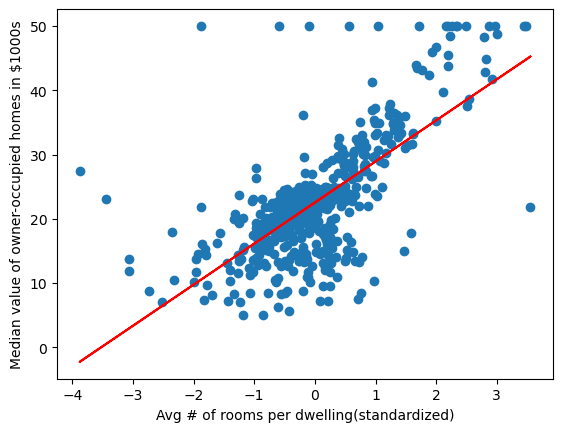

In [265]:
plt.scatter(x= X[:,1], y=Y) #Plotting the original data points
plt.plot(X[:,1], Y_pred, c="red")
plt.ylabel("Median value of owner-occupied homes in $1000s")
plt.xlabel("Avg # of rooms per dwelling(standardized)")
plt.show()

### 8. The above plot looks at the relationship between *rm* (an independent variable) and *mdev* (the dependent variable we are trying to predict). Create a single ordinary least squares (OLS) regression with a different independent variable (other than *rm*) from our data set. Once you have your predictions, plot the line of best fit with your chosen independent variable on the x-axis and *mdev* on the y-axis. **(2 points)**

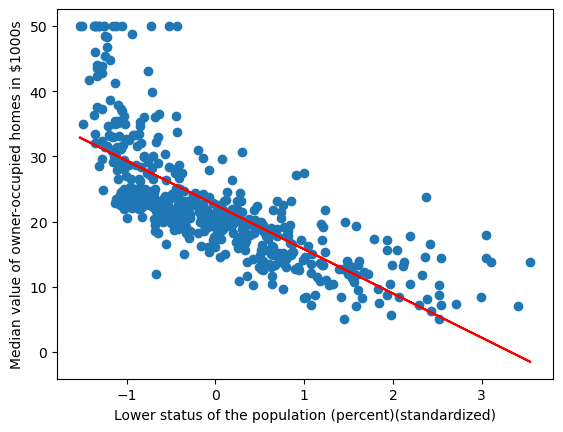

In [266]:
### implement your single regression model here
x_low = df.iloc[:, 11:12]
x_low=x_low.to_numpy()
x_low=prepare_matrix(x_low)
x_low[:,1]=standardize(x_low[:,1])
betas_crim = np.linalg.inv(x_low.T @ x_low) @ x_low.T @ y
Y_pred_crim = predict(x_low, betas_crim)

plt.scatter(x= x_low[:,1], y=Y) #Plotting the original data points
plt.plot(x_low[:,1], Y_pred_crim, c="red")
plt.ylabel("Median value of owner-occupied homes in $1000s")
plt.xlabel("Lower status of the population (percent)(standardized)")
plt.show()

NOTE: this is scaled, even if it doesn't look so, just because how many points are near zero or just below zero.

### 9.
To this point, you've trained a single variable linear regression on just the training data. This tells us how the model will perform on data we already have, but not on actual data we recieve in the future. To get a better understanding of how the data will run on unseen data, we need to split our data into training and testing data.


Now, train a single linear regression model using a train/test split. Identify how the mdoel does on the training vs testing data.

#### 9a. Split the data into a training and test split. In the training set, keep 80% of the observations. In the test set, keep the other 20% of observations. **(2 points)**

In [267]:
# Split into Training and Testing Sets (80% of the data should be in your training array and 20% of your data should be in your test array)
from sklearn.model_selection import train_test_split

def standardize_split(train, test):
    mean = np.mean(train, axis=0)
    sd = np.std(train, axis=0)
    standardized = (train-mean)/sd
    standardizedTest = (test-mean)/sd
    return standardized, standardizedTest

x_low = df.iloc[:, 11:12]
x_low = x_low.to_numpy()
x_low = prepare_matrix(x_low)

X_train, X_test, y_train, y_test = train_test_split(x_low, Y, test_size=0.2, random_state=48) #Random state so this is repeatable

X_train[:,1:], X_test[:,1:] = standardize_split(X_train[:,1:], X_test[:,1:])

#### 9b. With your training data, train the model by minimizing the Sum of Squared Errors (normalized SSE (SSE/n)). You will have one coefficient for the intercept term $(\beta_0)$ and another for your chosen independent variable ($\beta_1$). **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [268]:
# Train model by minimizing the (normalized) SSE.
# Note: dividing SSE by n does NOT change the optimal coefficients (it only rescales the objective).
# TODO: implement training below
betas_train = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

Y_pred_train = predict(X_train, betas_train)

print("Beta 0: "+str(betas_train[0]))
print("Beta 1 (Slope): "+str(betas_train[1]))

Beta 0: [22.34975248]
Beta 1 (Slope): [-6.70307937]


#### 9c. Using your trained model ($\beta$ coefficients), calculate your predictions on the training data set. Compare your predictions with the true values of *mdev* in the train set by computing the normalized SSE (SSE/n). Report your value of normalized SSE (SSE/n). **(5 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [269]:
# Evaluate your trained model on the training data.
# Compute the **normalized** SSE (SSE/n) on the TRAIN split.
# TODO: compute sse_train below

n_train = len(y_train)
sse_train = (np.sum((y_train-Y_pred_train)**2))/n_train
print(sse_train)

36.21409824849397


#### 9d. Now use your trained model to calculate your predictions on the test data set. Compute the normalized SSE (SSE/n) on the test data set. **(5 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [270]:
# Evaluate your trained model on the test data.
# Compute the **normalized** SSE (SSE/n) on the TEST split.
# TODO: compute sse_test below

Y_pred_test = predict(X_test, betas_train)

n_test = len(y_test)
sse_test = (np.sum((y_test-Y_pred_test)**2))/n_test
print(sse_test)

47.64210275580328


#### 9e. How does the SSE on the test set compare to the SSE on the training set? **(2 points)**

**Answer:**

The SSE on the test set is higher than the SSE on the training set. Test is around 50 and train is about 36.


### 9f. Plot (like in Question 7) your line of best fit over your training data. **(2 points)**

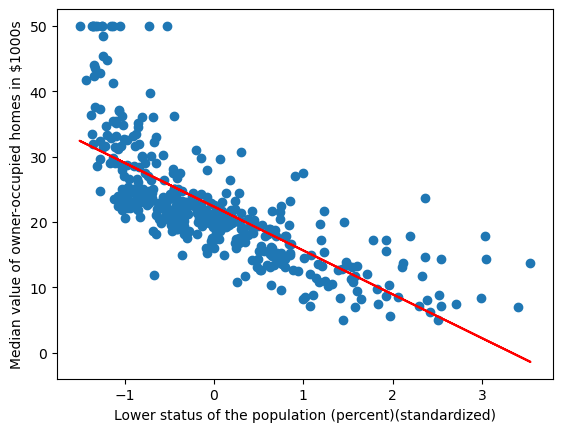

In [271]:
# Plot here

plt.scatter(x= X_train[:,1], y=y_train) #Plotting the original data points
plt.plot(X_train[:,1], Y_pred_train, c="red")
plt.ylabel("Median value of owner-occupied homes in $1000s")
plt.xlabel("Lower status of the population (percent)(standardized)")
plt.show()

### 9g. Plot (like in Question 7) your line of best fit over your test data. **(2 points)**

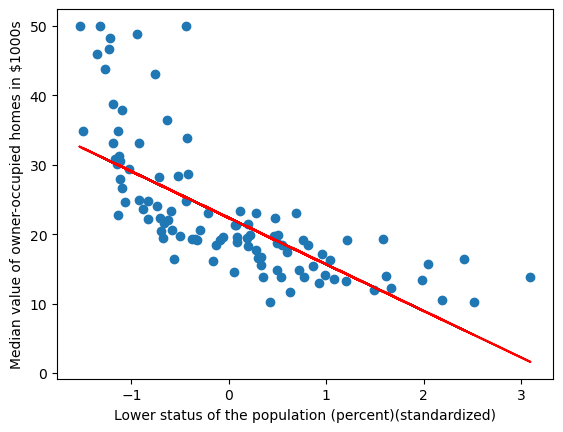

In [272]:
# Plot here

plt.scatter(x= X_test[:,1], y=y_test) #Plotting the original data points
plt.plot(X_test[:,1], Y_pred_test, c="red")
plt.ylabel("Median value of owner-occupied homes in $1000s")
plt.xlabel("Lower status of the population (percent)(standardized)")
plt.show()

### 10. The models you have created thus far are only examples of single ordinary least squares. What if we want to include more than one independent variable in our prediction? Train a multiple linear regression model which incorporates all of the available independent variables in the data set. Using your model, predict the median house value. Compare your results on the training data set vs the test data set again. **(10 points)**

> Reminder: when comparing train vs test error, use **normalized SSE = (1/n)·∑(y-ŷ)^2**.


In [273]:
### Modify your code for multiple linear regression (use all non-label columns available to train a model to predict median house value)
#Hint: remove the last column because we cannot use the dependent variable in the model

x = df.iloc[:, :-1]

x = x.to_numpy()

Xall = prepare_matrix(x)

X_train, X_test, y_train, y_test = train_test_split(Xall, Y, test_size=0.2, random_state=48)

X_train[:,1:], X_test[:,1:] = standardize_split(X_train[:,1:], X_test[:,1:])

betas_all_train = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

Y_pred_all_train = predict(X_train, betas_all_train)

n_train_all = len(y_train)
sse_train_all = (np.sum((y_train-Y_pred_all_train)**2))/n_train_all

Y_pred_all_test = predict(X_test, betas_all_train)

n_test_all = len(y_test)
sse_test_all = (np.sum((y_test-Y_pred_all_test)**2))/n_test_all

print("SSE Train: "+str(sse_train_all))
print("SSE Test: "+str(sse_test_all))

SSE Train: 20.175550392447708
SSE Test: 32.48479989929397


### 11. The model you made in the previous question only had linear terms of our features. Sometimes, we want to capture more complicated relationships between variables. To add more complexity to our model, experiment with differnet polynomial models. For each model, try to think about whether you may be overfitting or underfitting to the training data. Again, compare your performnance on the training data vs the testing data.

#### 11a. Modify the design matrix to include polynomial terms of degree 2. (Hint: add squared values of existing columns to the deign matrix X). Calculate the normalized SSE (SSE/n) on the training and testing data sets. **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [ ]:
### Modify for polynomial regression (degree 2)
# Reminder: when reporting SSE in this section, use **normalized SSE** = sum((y - yhat)^2) / n.
# TODO: build your degree-2 design matrix, fit coefficients, and compute train/test normalized SSE.

def prepare_matrix_2deg(x):
    n = len(x)
    X = np.column_stack((np.ones(n), x, x**2))
    return X

x = df.iloc[:, 11:12]

x = x.to_numpy()

X2d = prepare_matrix_2deg(x)

X_train, X_test, y_train, y_test = train_test_split(X2d, Y, test_size=0.2, random_state=48)

X_train[:,1:], X_test[:,1:] = standardize_split(X_train[:,1:], X_test[:,1:])

betas_2d_train = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

Y_pred_2d_train = predict(X_train, betas_2d_train)

n_train_2d = len(y_train)
sse_train_2d = (np.sum((y_train-Y_pred_2d_train)**2))/n_train_2d

Y_pred_2d_test = predict(X_test, betas_2d_train)

n_test_2d = len(y_test)
sse_test_2d = (np.sum((y_test-Y_pred_2d_test)**2))/n_test_2d

print("SSE Train: "+str(sse_train_2d))
print("SSE Test: "+str(sse_test_2d))
print("This might be a bit underfit is my guess")

NameError: name 'df' is not defined

#### 11aa. After fitting your degree-2 model, make a quick visualization for sanity-checking. **(5 points)**

Using the **same single feature** you used back in Q9 (your chosen independent variable), plot:
1. The original data points \((x, y)\) as a scatter plot.
2. The fitted quadratic curve \(\hat{y} = a + bx + cx^2\) on top of the scatter plot.

> Tip: sort the x-values before plotting the curve so the line looks smooth.



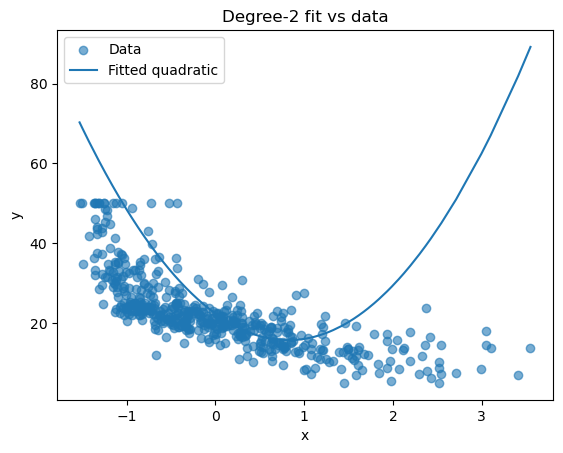

In [ ]:
# 11aa: Plot datapoints and fitted quadratic yhat = a + b x + c x^2 (for your chosen feature from Q9)
# TODO: Fill in `x_feature`, `y_true`, and the coefficients a, b, c from your degree-2 fit.

import numpy as np
import matplotlib.pyplot as plt

x = df.iloc[:, 11:12]

x = x.to_numpy()

X2daa = prepare_matrix_2deg(x)

X2daa[:,1:] = standardize(X2daa[:,1:])

x_feature = X2daa[:,1]   # shape (n,) # This code is different than before but plots the same feature.
y_true = Y # shape (n,)
a, b, c = betas_2d_train[0], betas_2d_train[1], betas_2d_train[2]# scalars (from your fitted quadratic on this feature)
# Make a smooth curve
x_sorted = np.sort(x_feature)
y_curve = a + b * x_sorted + c * (x_sorted ** 2)

plt.figure()
plt.scatter(x_feature, y_true, alpha=0.6, label="Data")
plt.plot(x_sorted, y_curve, label="Fitted quadratic")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Degree-2 fit vs data")
plt.legend()
plt.show()

#### 11b. To test how our model performs as we change the degree of our model. Train models of degree 1 to degree 8. This will result in 8 different models.  For each model you create, save the Sum of Squared Errors (normalized SSE (SSE/n)) on the training and test data set respectively. We will use them for the next step to plot how they change as the model becomes more complex. **(20 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [276]:
### Fit polynomial models of degrees 1-8, save training and testing errors
# Reminder: store **normalized** SSE values for each split:
#   sse_k_train = sum((y_train - yhat_train)^2) / len(y_train)
#   sse_k_test  = sum((y_test  - yhat_test )^2) / len(y_test)
# TODO: implement loop over degrees below and save errors for plotting.

x = df.iloc[:, 11:12]

x = x.to_numpy()

train_output = []
test_output  = []

def prepare_matrix_deg(x, degree):
    X = np.column_stack([x**d for d in range(degree+1)]) # d=0 is a way that we don't need to include np.ones(n) #Using a list comprehension
    return X

degrees = range(1, 9)

for d in degrees:
    Xdeg = prepare_matrix_deg(x, d)
    X_train, X_test, y_train, y_test = train_test_split(Xdeg, Y, test_size=0.2, random_state=48)
    X_train[:,1:], X_test[:,1:] = standardize_split(X_train[:,1:], X_test[:,1:])
    #Train
    betas_deg = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
    #Test
    train_output.append((np.sum((y_train-predict(X_train, betas_deg))**2))/len(y_train))
    test_output.append((np.sum((y_test-predict(X_test, betas_deg))**2))/len(y_test))

### Overfitting

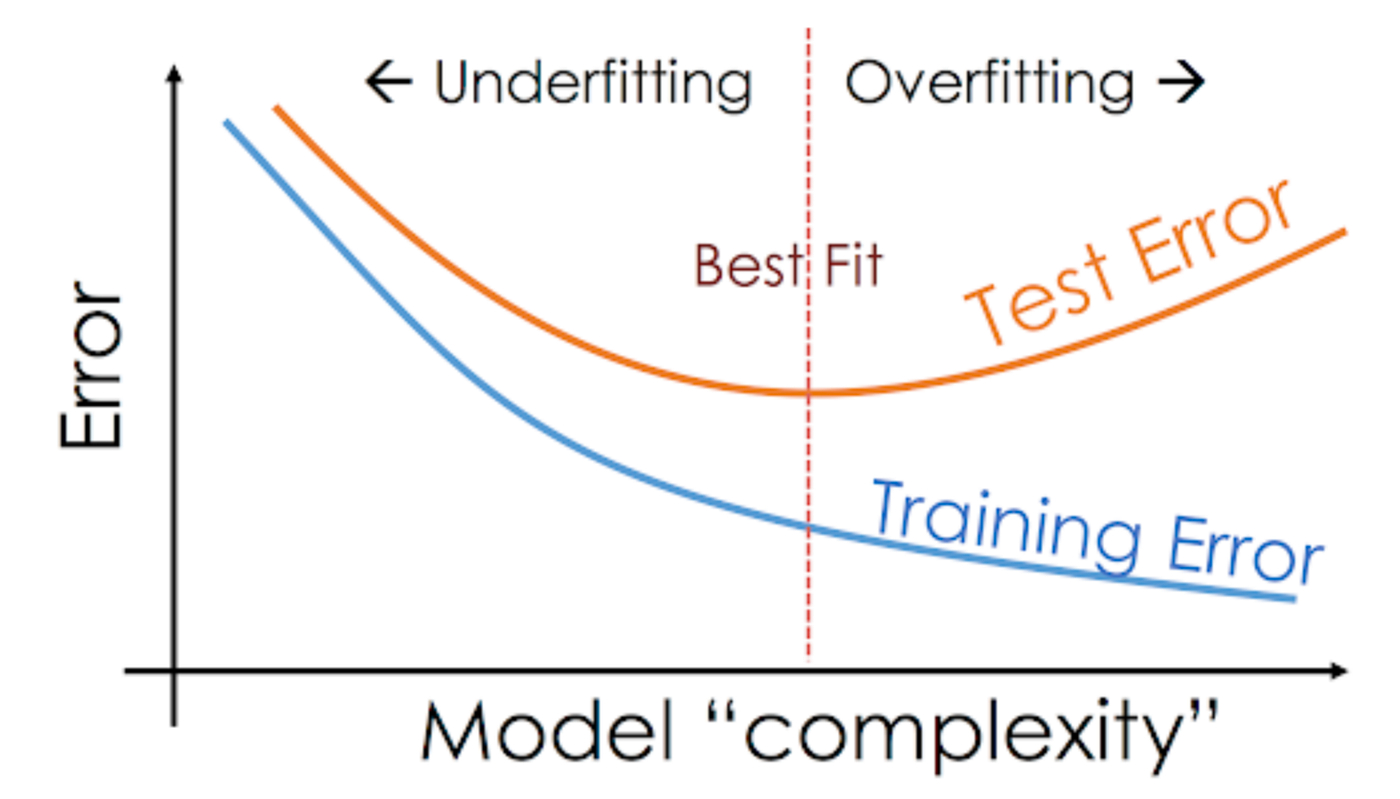

#### 11c. Using the training and testing normalized SSE (SSE/n) you calculated in the previous question, plot the errors for each model complexity. In this plot, the x-axis will be the model complexity (degree of the model) and the y-axis will be the normalized SSE (SSE/n) you calculated. What can you determine from this plot? How does the error on the training data set compare to the error on the testing data set as the degree of the model increases? **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


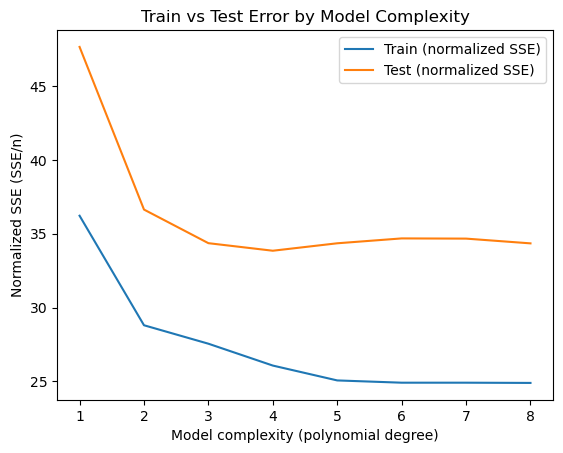

In [277]:
###Graph training and testing errors on same line plot to show overfitting
#After you correct SSE everywhere (use normalized SSE), make sure this plot renders and matches the reference image above.
#TODO: replace `degrees`, `train_errors`, `test_errors` with your actual arrays/lists.

import matplotlib.pyplot as plt

# Example placeholders (replace with your computed values)
degrees = list(range(1, 9))
train_errors = train_output
test_errors = test_output

plt.figure()
plt.plot(degrees, train_errors, label="Train (normalized SSE)")
plt.plot(degrees, test_errors, label="Test (normalized SSE)")
plt.xlabel("Model complexity (polynomial degree)")
plt.ylabel("Normalized SSE (SSE/n)")
plt.title("Train vs Test Error by Model Complexity")
plt.legend()
plt.show()

We can determine from this plot, that around 4 polynomials is the best for accuracy, there is still a gap between train and test accuracy. We are underfitting before 4 and over fitting after 4 it seems. Training accuracy and test accuracy first improve before 4 and then diverge with test accuracy getting worse and training accuracy gets better.